In [1]:
%matplotlib inline
import brainmass
import brainstate
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
brainstate.random.seed(0)
brainstate.environ.set(dt=0.1 * u.ms)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


# From Activity to Signals

Neural mass models produce *neural activity* — firing rates, membrane potentials,
synaptic currents. But experiments do not measure activity directly; they measure
**signals**: a BOLD time course from fMRI, voltages from EEG, magnetic fields from
MEG. A **forward model** is the biophysics that turns simulated activity into a
predicted signal, so a model can be compared to (and fit against) real data.

This page explains the theory of the two forward models ``brainmass`` ships — the
hemodynamic (BOLD) model and the electromagnetic (EEG/MEG) lead-field model — what
each observable measures, and the assumptions baked into each. The hands-on version
is {doc}`/tutorials/05_forward_models`; the architectural role of this layer is in
{doc}`/concepts/architecture_overview`.

## The forward-model idea

Every forward model is a map

$$
\text{neural activity } a(t) \;\xrightarrow{\;\text{biophysics}\;}\; \text{signal } y(t).
$$

What distinguishes the modalities is *what physics does the mapping* and *what is
actually measured*:

| Modality | Measures | Forward physics | Timescale |
|---|---|---|---|
| **fMRI / BOLD** | blood-oxygenation changes | neurovascular coupling (hemodynamics) | seconds (slow) |
| **EEG** | scalp electric potential | volume conduction of dipolar currents | milliseconds (fast) |
| **MEG** | extracranial magnetic field | magnetic field of the same currents | milliseconds (fast) |

In ``brainmass`` every forward model is itself a **differentiable** module, so a
loss defined in *signal space* (BOLD, EEG, or MEG) backpropagates all the way to
the underlying neural parameters — the end-to-end differentiability discussed in
{doc}`/concepts/why_differentiable`.

## BOLD: the hemodynamic forward model

fMRI does not see neurons; it sees **blood**. Local neural activity raises metabolic
demand, which (via *neurovascular coupling*) increases blood flow, blood volume,
and the local ratio of oxygenated to deoxygenated haemoglobin. Because oxygenated
and deoxygenated blood have different magnetic susceptibilities, this changes the
MR signal — the **blood-oxygen-level-dependent (BOLD)** contrast. The forward model
is the chain *activity → flow → volume & deoxyhaemoglobin → BOLD*.

### The Balloon–Windkessel model

``brainmass.BOLDSignal`` implements the Balloon–Windkessel model of Friston et al.
(2003). For each region, synaptic activity $z_i$ drives a vasodilatory signal
$x_i$, which changes inflow $f_i$, blood volume $v_i$, and deoxyhaemoglobin content
$q_i$:

$$
\begin{aligned}
\dot{x}_i &= z_i - \kappa_i x_i - \gamma_i (f_i - 1), \\
\dot{f}_i &= x_i, \\
\tau_i \dot{v}_i &= f_i - v_i^{1/\alpha}, \\
\tau_i \dot{q}_i &= \frac{f_i}{\rho}\bigl[1 - (1-\rho)^{1/f_i}\bigr] - q_i\,v_i^{\,1/\alpha - 1},
\end{aligned}
$$

with the measured BOLD a static nonlinear read-out of volume and deoxyhaemoglobin,

$$
\mathrm{BOLD}_i = V_0\bigl[k_1(1 - q_i) + k_2(1 - q_i/v_i) + k_3(1 - v_i)\bigr],
$$

where $\rho$ is the resting oxygen-extraction fraction, $\alpha$ is Grubb's
exponent, $\tau$ the hemodynamic transit time, and $k_1, k_2, k_3$ are fixed
biophysical constants. The key assumptions: the response is **regional and local**
(no hemodynamic coupling between regions), and it is a **slow temporal low-pass** —
the haemodynamics blur fast neural dynamics into a response that peaks several
seconds after activity.

### The convolution (HRF) shortcut

The full ODE is detailed but stiff and slow. For fitting, ``brainmass`` also offers
``HRFBold``: a **single linear convolution** of (downsampled) activity with a
closed-form **hemodynamic response function** $h(t)$,

$$
\mathrm{BOLD}(t) = k_1 V_0\,\bigl(h * y_{\downarrow}\bigr)(t) - 1,
$$

using kernels such as the canonical first-order Volterra (damped oscillator) or a
mixture of gammas. This is fast, simple, and **differentiable in its handful of
scalar parameters** — the right tool when the BOLD model sits inside an
optimisation loop. Empirically the two routes track each other closely (best-lag
correlation $\approx 0.98$ on a slow drive), differing mainly in their intrinsic
latency. So: ``BOLDSignal`` when biophysical realism matters, ``HRFBold`` when you
are fitting.

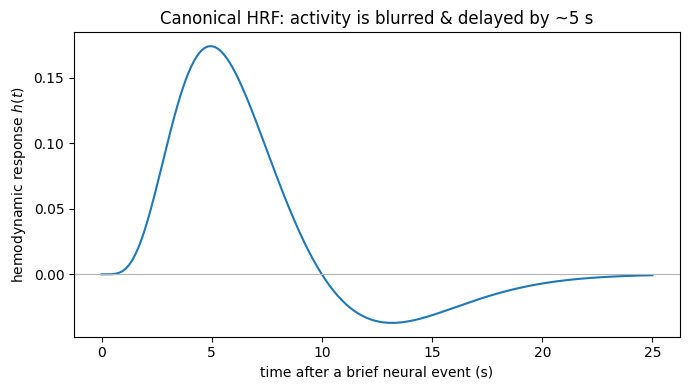

In [2]:
import brainmass
import brainunit as u
import numpy as np
import matplotlib.pyplot as plt

# Visualise a canonical hemodynamic response function: the impulse response that
# convolution-BOLD applies to neural activity. Note the ~5-6 s peak and post-undershoot.
kernel = brainmass.MixtureOfGammasHRFKernel()
t = np.linspace(0.0, 25.0, 400) * u.second
h = kernel(t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.asarray(t.to_decimal(u.second)), np.asarray(h))
ax.axhline(0.0, color='0.7', lw=0.8)
ax.set_xlabel('time after a brief neural event (s)')
ax.set_ylabel('hemodynamic response $h(t)$')
ax.set_title('Canonical HRF: activity is blurred & delayed by ~5 s')
fig.tight_layout()
plt.show()

The HRF makes the BOLD assumptions visceral: a brief burst of neural activity
produces a response that **peaks several seconds later** and undershoots before
returning to baseline. fMRI therefore reports a slow, lagged, smoothed image of the
underlying fast dynamics — which is exactly why whole-brain BOLD models compare
*functional connectivity* (correlation structure over minutes) rather than
millisecond waveforms.

## EEG / MEG: the lead-field forward model

EEG and MEG see **electromagnetism**. Synchronous post-synaptic currents in
populations of pyramidal neurons act, at a distance, like **equivalent current
dipoles** (ECDs). Each region's dipole sets up an electric potential (measured by
EEG electrodes) and a magnetic field (measured by MEG sensors) throughout the head.
Because the quasi-static Maxwell equations are **linear**, the mapping from source
currents to sensors is a single matrix multiply.

### The lead-field equation

``brainmass``'s ``LeadFieldModel`` implements

$$
\mathbf{y}(t) \;=\; \mathbf{s}(t)\,\mathbf{L} \;+\; \boldsymbol{\varepsilon}(t),
$$

where

- $\mathbf{s}(t) \in \mathbb{R}^{R}$ is the **equivalent current dipole moment** per
  region (typically in $\mathrm{nA\cdot m}$), obtained from the NMM observable via a
  scale factor.
- $\mathbf{L} \in \mathbb{R}^{R \times M}$ is the **lead-field** (gain) matrix — the
  signal each unit dipole produces at each of $M$ sensors. Its units are
  $\mathrm{V/(nA\cdot m)}$ for EEG and $\mathrm{T/(nA\cdot m)}$ for MEG.
- $\mathbf{y}(t) \in \mathbb{R}^{M}$ are the sensor measurements (volts for EEG,
  tesla for MEG).
- $\boldsymbol{\varepsilon}(t) \sim \mathcal{N}(\mathbf{0}, \boldsymbol{\Sigma})$ is
  additive sensor noise.

The lead field $\mathbf{L}$ encodes all the head geometry and physics — the
conductivity of brain, skull, and scalp; sensor positions; source orientations — and
is normally precomputed by a **head model** (boundary- or finite-element method) in
a tool such as MNE, FieldTrip, or Brainstorm. ``brainmass`` consumes that
$\mathbf{L}$ and provides the differentiable, **unit-safe** projection, aggregating
vertex-level lead fields to region level when needed.

### What each modality assumes — and how they differ

The *same* dipolar sources feed both EEG and MEG, but the physics treats them
differently:

- **EEG** measures scalp **potential**. The currents must cross the **skull**,
  whose low conductivity *smears* the potential — EEG has lower spatial resolution
  but sees all source orientations, including radial (pointing out of the head).
- **MEG** measures the **magnetic field**, which the skull barely perturbs (magnetic
  permeability is nearly uniform), so MEG is less smeared. But a radially-oriented
  dipole in a spherically symmetric head produces *no external magnetic field* —
  MEG is largely **blind to radial sources** and most sensitive to tangential ones.

Shared assumptions: the **quasi-static** approximation (no wave propagation at these
frequencies, so the map is an instantaneous linear projection), a **fixed source
space** (one dipole per region, with a chosen orientation), and a head conductivity
model. These assumptions are what make the forward map a constant matrix $\mathbf{L}$
— and what make the *inverse* problem (recovering sources from sensors)
ill-posed, which is precisely why a *generative* forward model like this one is
useful.

> A units caveat worth flagging (see {doc}`/tutorials/05_forward_models`): the
> ``EEGLeadFieldModel`` helper is tuned for an mV neural source. For MEG from an mV
> source, drive the base ``LeadFieldModel`` with an explicit ``scale`` and
> ``sensor_unit=u.tesla`` so the output lands in tesla.

In [3]:
import brainmass
import brainstate
import brainunit as u
import numpy as np
import jax.numpy as jnp

brainstate.random.seed(0)

# A tiny EEG forward projection: R=4 source regions -> M=6 sensors.
# The lead field carries the EEG sensor unit per dipole moment, mV / (nA*m).
R, M = 4, 6
L = jnp.asarray(np.random.randn(R, M)) * (u.mV / (u.nA * u.meter))
eeg = brainmass.EEGLeadFieldModel(in_size=(R,), out_size=(M,), L=L)

# A short window of regional dipole activity (mV NMM observable), (T, R).
T = 50
sources = (jnp.array([1.0, -0.5, 0.8, 0.2]) * jnp.ones((T, R))) * u.mV
sensors = eeg.update(sources)   # linear lead-field projection -> sensor space

print('source activity (T x R):', sources.shape, ' ->  sensors (T x M):', sensors.shape)
print('sensor output unit:', u.get_unit(sensors))   # mV, via s @ L

source activity (T x R): (50, 4)  ->  sensors (T x M): (50, 6)
sensor output unit: mV


The four regional sources are linearly mixed by the lead field into six sensor
measurements, unit-correctly (volts out). The same $\mathbf{L}$-style multiply,
with a tesla-valued lead field, gives MEG. Because the projection is differentiable,
a loss on the *sensor* signal flows back to the neural model — closing the loop from
parameters all the way to the measured signal.

## Choosing a forward model

| You are modelling… | Use | Why |
|---|---|---|
| Resting-state fMRI / BOLD FC | ``BOLDSignal`` or ``HRFBold`` | hemodynamics; FC over minutes |
| **Fitting** in BOLD space | ``HRFBold`` | fast, differentiable convolution |
| Biophysically realistic BOLD | ``BOLDSignal`` | full Balloon–Windkessel ODE |
| EEG (scalp potentials) | ``EEGLeadFieldModel`` | volume conduction, all orientations |
| MEG (magnetic fields) | ``LeadFieldModel`` / ``MEGLeadFieldModel`` | tangential-source sensitivity |

In all cases the forward model is the *generative* link between a neural mass model
and data — and in ``brainmass`` it is one more differentiable module in the chain,
not a separate post-processing step.

## Key takeaways

- A **forward model** maps simulated neural activity to a measured signal; the
  modality determines the physics and what is observed.
- **BOLD** is hemodynamic, regional, and slow: a Balloon–Windkessel ODE
  (``BOLDSignal``) or an HRF convolution (``HRFBold``) that blurs and delays
  activity by seconds.
- **EEG/MEG** are electromagnetic and fast: a linear **lead-field** projection of
  dipolar source currents, with EEG smeared by the skull and MEG blind to radial
  sources.
- Every forward model in ``brainmass`` is **differentiable and unit-safe**, so
  signal-space losses backpropagate to neural parameters.

## See also

- {doc}`/tutorials/05_forward_models` — running BOLD and EEG/MEG forward models.
- {doc}`/concepts/architecture_overview` — the observation layer's place in the stack.
- {doc}`/concepts/why_differentiable` — why end-to-end differentiability matters.
- {doc}`/reference/index` — the forward-model and observation API.

## References

- Friston, K. J., Harrison, L., & Penny, W. (2003). Dynamic causal modelling.
  *NeuroImage*, 19(4), 1273–1302.
- Buxton, R. B., Wong, E. C., & Frank, L. R. (1998). Dynamics of blood flow and
  oxygenation changes during brain activation: the balloon model. *Magnetic
  Resonance in Medicine*, 39(6), 855–864.
- Hämäläinen, M., Hari, R., Ilmoniemi, R. J., Knuutila, J., & Lounasmaa, O. V.
  (1993). Magnetoencephalography — theory, instrumentation, and applications to
  noninvasive studies of the working human brain. *Reviews of Modern Physics*,
  65(2), 413–497.
- Nunez, P. L., & Srinivasan, R. (2006). *Electric Fields of the Brain: The
  Neurophysics of EEG* (2nd ed.). Oxford University Press.